<a href="https://colab.research.google.com/github/kangtayie/Machine-Learning_class/blob/main/133pgimage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import matplotlib.pyplot as plt

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

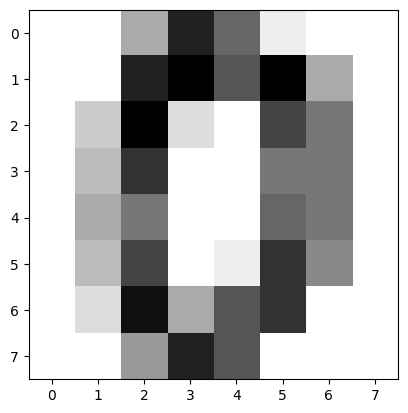

In [42]:
digits = datasets.load_digits()
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')

In [43]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

In [44]:
# KNN 비교 k=5 vs k=6 vs k=7
from sklearn.neighbors import KNeighborsClassifier

k_values = [5, 6, 7]
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(metrics.accuracy_score(y_test, y_pred))
    print(f"--- KNN (k={k}) ---")
    print(metrics.classification_report(y_test, y_pred))

--- KNN (k=5) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.00        44
           3       0.98      0.98      0.98        41
           4       1.00      0.96      0.98        26
           5       1.00      1.00      1.00        43
           6       1.00      1.00      1.00        32
           7       0.95      1.00      0.97        36
           8       0.96      1.00      0.98        23
           9       1.00      0.95      0.97        38

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

--- KNN (k=6) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.0

In [45]:
# 랜덤 포레스트 분류
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = metrics.accuracy_score(y_test, y_pred_rf)
print(acc_rf)

print("--- Random Forest ---")
print(metrics.classification_report(y_test, y_pred_rf))

0.9861111111111112
--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        47
           2       1.00      1.00      1.00        44
           3       0.98      1.00      0.99        41
           4       1.00      0.96      0.98        26
           5       1.00      0.98      0.99        43
           6       1.00      0.97      0.98        32
           7       0.97      1.00      0.99        36
           8       0.88      1.00      0.94        23
           9       1.00      0.95      0.97        38

    accuracy                           0.99       360
   macro avg       0.98      0.99      0.98       360
weighted avg       0.99      0.99      0.99       360



In [46]:
# 결정트리 분류
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = metrics.accuracy_score(y_test, y_pred_dt)
print(acc_dt)

print("--- Decision Tree ---")
print(metrics.classification_report(y_test, y_pred_dt))

0.8527777777777777
--- Decision Tree ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.79      0.79      0.79        47
           2       0.85      0.77      0.81        44
           3       0.79      0.93      0.85        41
           4       0.85      0.85      0.85        26
           5       1.00      0.88      0.94        43
           6       0.97      0.88      0.92        32
           7       0.87      0.92      0.89        36
           8       0.63      0.83      0.72        23
           9       0.83      0.79      0.81        38

    accuracy                           0.85       360
   macro avg       0.86      0.86      0.85       360
weighted avg       0.86      0.85      0.85       360



In [47]:
# 로지스틱 회귀
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = metrics.accuracy_score(y_test, y_pred_lr)
print(acc_lr)

print("--- Logistic Regression ---")
print(metrics.classification_report(y_test, y_pred_lr))

0.9694444444444444
--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       0.98      0.98      0.98        47
           2       1.00      1.00      1.00        44
           3       1.00      0.98      0.99        41
           4       0.96      0.96      0.96        26
           5       1.00      0.93      0.96        43
           6       1.00      0.97      0.98        32
           7       0.95      1.00      0.97        36
           8       0.82      1.00      0.90        23
           9       0.94      0.89      0.92        38

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



[5]


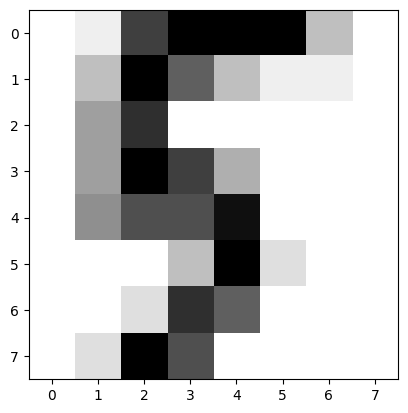

In [48]:
plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
y_pred = knn.predict([X_test[10]])
print(y_pred)

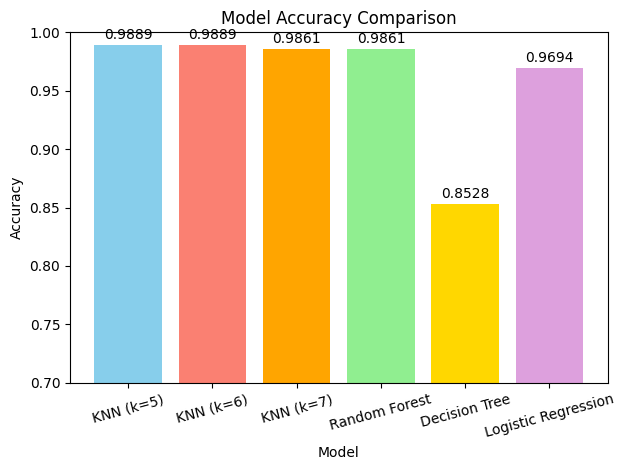

In [49]:
# 비교 시각화
model_names = [f'KNN (k={k})' for k in k_values] + ['Random Forest', 'Decision Tree', 'Logistic Regression']
all_accuracies = accuracies + [acc_rf, acc_dt, acc_lr]

colors = ['skyblue', 'salmon', 'orange', 'lightgreen', 'gold', 'plum']
bars = plt.bar(model_names, all_accuracies, color=colors[:len(model_names)])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)
for bar, acc in zip(bars, all_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005, f'{acc:.4f}', ha='center')
plt.tight_layout()
plt.show()